# ssGSEA signature enrichment

**ssGSEA 基因集富集**

Score the public IMvigor210 demonstration matrix (872 features × 348 samples). This is a restricted feature panel, not a complete transcriptome; only signatures with sufficient overlap are returned.

This notebook uses public [IOBR release fixtures](https://github.com/IOBR/IOBR/releases/tag/data-v1.0). Source URLs and checksums are in [data/manifest.json](data/manifest.json). Figures are descriptive; no clinical outcome labels are supplied.

**Setup:** from the repository root, install with `python -m pip install ".[tutorials]"`. Restart the notebook kernel after installation.

In [1]:
%matplotlib inline
from pathlib import Path
from time import perf_counter
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import iobrx

# Works from the repository root or from the tutorials directory.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tutorials" / "_common.py").exists())
sys.path.insert(0, str(ROOT / "tutorials"))
from _common import (configure, load, tpm_input, runtime_info, numeric_scores,
                     short_samples, clean_labels, panel, heatmap, scatter,
                     stacked, composition_figure, fractions, save_figure, save_result, COLORS, TEAL, RUST, NAVY)
configure(2)
iobrx.set_threads(8)
display(runtime_info())


{'iobrx': '0.2.0',
 'threads': 8,
 'native_available': True,
 'native_reason': None,
 'sorting': 'numpy CPU dispatch',
 'requires_avx512': False,
 'bundled_openblas_found': True,
 'versions': {'numpy': '2.2.6',
  'pandas': '2.3.3',
  'scipy': '1.16.3',
  'scikit-learn': '1.7.2',
  'iobrpy': '0.2.1',
  'gseapy': '1.3.1',
  'matplotlib': '3.10.9'}}

## 1. Inspect the input / 检查输入

Expression matrices are **genes × samples**. The analysis uses every sample; any figure subset is stated explicitly.

In [2]:
expression = load("imvigor210_eset")
input_shape = expression.shape
display(expression.iloc[:5, :4])


,SAMf2ce197162ce,SAM698d8d76b934,SAMc1b27bc16435,SAM85e41e7f33f9
rownames,,,,
LOC100093631,3.100940,2.820764,3.705899,2.810128
LOC100126784,-2.623775,-4.256052,-5.410445,-2.076004
LOC100128108,-1.501784,0.520052,-0.766588,-2.076004
LOC100128288,-0.336198,-1.220428,-1.951013,-1.258868
LOC100128361,0.254547,0.292385,-0.200991,-0.025377


## 2. Run the analysis / 运行分析

The timer covers the call below, including its resource setup. Data loading above and plotting below are excluded. This is a single run; repeated benchmark medians are reported separately in the README.

In [3]:
started = perf_counter()
result = iobrx.calculate_sig_score(expression, "signature_collection", method="ssgsea", mini_gene_count=3, adjust_eset=True, n_threads=8)
elapsed = perf_counter() - started
display(save_result(result, "05_signature_ssgsea", elapsed, input_shape))

Completed in 0.574 s; input 872 features × 348 samples.


,analysis,seconds,input_shape,output_shapes,threads
0,05_signature_ssgsea,0.574062,"[872, 348]","{'result': [348, 32]}",8


In [4]:
display(result.head() if isinstance(result, pd.DataFrame) else {key: value.shape if isinstance(value, pd.DataFrame) else list(value) for key, value in result.items()})

Term,ID,Antigen_Processing_and_Presentation_Li_et_al,Antimicrobials_Li_et_al,Base_excision_repair,CD8_c1_Tex,CD_8_T_effector,CellCycle_Reg,Cell_cycle,Co_inhibition_T_cell_Rooney_et_al,Cytokines_Li_et_al,...,Pyrimidine_Metabolism,TCR_signaling_Pathway_Li_et_al,TIP_Killing_of_cancer_cells_2,TIP_Priming_and_activation_1,TIP_Priming_and_activation_2,TIP_Recognition_of_cancer_cells_by_T_cells_1,TMEscoreA_CIR,TMEscoreA_plus,TMEscoreB_CIR,TMEscore_CIR
0,SAM00b9e5c52da9,0.385470,0.328786,0.308823,-0.013044,0.019039,0.437138,0.418479,0.087173,0.274467,...,0.334864,0.096127,0.223608,0.052243,0.052243,0.341668,0.233591,0.200141,0.273387,-0.039796
1,SAM0257bbbbd388,0.376284,0.337696,0.349203,-0.072346,0.016017,0.431195,0.448575,-0.019032,0.166174,...,0.356885,0.072831,0.151420,-0.049502,-0.049502,0.303140,0.252528,0.208202,0.259228,-0.006700
2,SAM025b45c27e05,0.357702,0.318005,0.306970,-0.092194,-0.105520,0.429715,0.423161,0.021344,0.312109,...,0.337336,0.046280,0.217365,-0.017566,-0.017566,0.298838,0.184748,0.124741,0.415794,-0.231046
3,SAM032c642382a7,0.468551,0.398006,0.335905,0.162133,0.249370,0.456882,0.464964,0.224756,0.285565,...,0.388981,0.225959,0.310974,0.204629,0.204629,0.430949,0.378226,0.385764,0.120457,0.257768
4,SAM04c589eb3fb3,0.451828,0.422359,0.332210,0.043497,0.160511,0.440725,0.434961,0.070294,0.296367,...,0.374680,0.159655,0.270320,0.057407,0.057407,0.360560,0.350063,0.306514,0.335874,0.014189


## 3. Visualize and export / 作图与导出

White background, restrained colors, thin axes and editable vector text. Heatmap z-scores are display-only; exported result tables keep the original values. `S01`, `S02`, … follow the sample order of each displayed matrix; the mapping is printed below.

For the IMvigor210 heatmaps, only the first 30 samples are shown (24 per panel in the integration notebook); scoring and distributions use all 348.

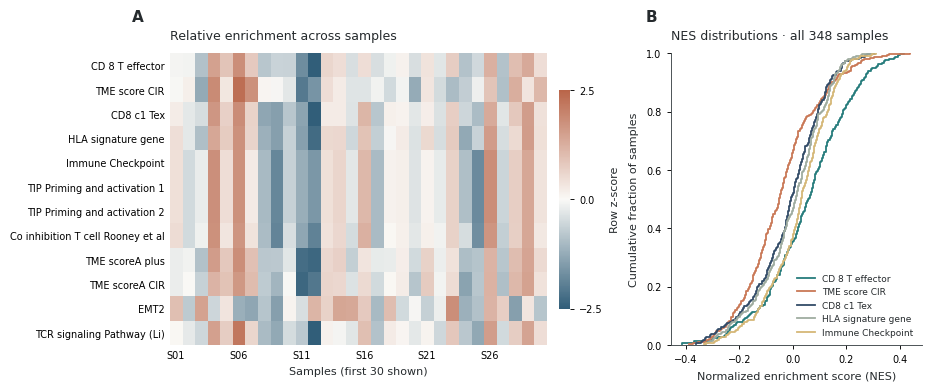

In [5]:
scores = numeric_scores(result).astype(float)
features = scores.std().nlargest(12).index
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), gridspec_kw={"width_ratios": [1.5, 1]}, layout="constrained")
heatmap(axes[0], scores[features].T)
selected = features[:5]
for i, name in enumerate(selected):
    values = np.sort(scores[name].to_numpy())
    axes[1].step(values, np.arange(1, len(values)+1) / len(values), where="post", color=COLORS[i], linewidth=1.3, label=clean_labels([name])[0])
axes[1].set(xlabel="Normalized enrichment score (NES)", ylabel="Cumulative fraction of samples", ylim=(0, 1))
axes[1].legend(loc="lower right", ncol=1, fontsize=6.5)
panel(axes[0], "A", "Relative enrichment across samples")
panel(axes[1], "B", "NES distributions · all 348 samples")
save_figure(fig, '05_signature_ssgsea')


In [6]:
sample_ids = expression.columns if "expression" in globals() else counts.columns if "counts" in globals() else tpm.columns
display(pd.DataFrame({"plot_label": short_samples(sample_ids), "original_sample_id": sample_ids}).head(30))

,plot_label,original_sample_id
0,S01,SAMf2ce197162ce
1,S02,SAM698d8d76b934
2,S03,SAMc1b27bc16435
3,S04,SAM85e41e7f33f9
4,S05,SAMf275eb859a39
5,S06,SAM7f0d9cc7f001
6,S07,SAM4305ab968b90
7,S08,SAMcf018fee2acd
8,S09,SAMb2f1d0e54ece
9,S10,SAMcc4675f394a1


## 4. Interpretation and limits / 解读与边界

The output is NES, including IOBRpy/GSEApy normalization and tie handling. A score summarizes a gene set; it is not a gene-level fold change or a significance p-value. At least five overlapping genes are required for the standalone ssGSEA method.

**Reusing this tutorial:** replace the input-loading cell with your own `pd.read_csv(..., index_col=0)`; keep the matrix orientation, identifier type and expression scale consistent with this example. Check gene overlap before interpreting estimates.

Figures are written to `tutorials/figures/05_signature_ssgsea.png`, `.pdf`, and `.svg`. Compact output tables and timing metadata are written to `tutorials/results/`. Large count/TPM matrices remain in `result`; save them explicitly with `result.to_parquet(...)` if needed.